# UZH-FPV + Spyx Architecture Lab

This notebook targets the UZH-FPV Drone Racing dataset at https://fpv.ifi.uzh.ch/datasets/.

Status in Tonic:
- No direct `tonic.datasets` class for UZH-FPV in this environment.

Dataset facts from the public release:
- formats: ROS bags and ZIP/text exports
- sensors: DAVIS events/images, Snapdragon images + IMU, Leica ground truth
- event stream message type in bags: `dvs_msgs/EventArray`
- GT availability: some sequences are public, some are withheld for benchmark use
- license: CC BY-NC-SA 3.0

Research focus:
- aggressive event-based flight perception
- compact and hardware-friendly Spyx architectures
- Optuna search over event encoders tuned for high-speed racing dynamics

The notebook is intentionally usable before full dataset ingestion: it supports local-file discovery and falls back to synthetic event tensors that mimic sparse, bursty racing trajectories.

In [3]:
from pathlib import Path

import haiku as hk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

import spyx.models as fm

DATA_ROOT = Path("../data/UZH_FPV")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
print("DATA_ROOT:", DATA_ROOT.resolve())


def tonic_has_uzh_fpv():
    import tonic.datasets as d
    names = {n.lower() for n in dir(d)}
    return any(k in names for k in ["uzhfpv", "fpv", "uzh_fpv"])


def discover_fpv_layout(root: Path) -> dict[str, list[str]]:
    result = {}
    for name in ["calib", "raw", "output"]:
        path = root / name
        if path.exists():
            result[name] = sorted(p.name for p in path.iterdir())[:12]
        else:
            result[name] = []
    return result


print("tonic_has_uzh_fpv =", tonic_has_uzh_fpv())
layout = discover_fpv_layout(DATA_ROOT)
layout

DATA_ROOT: /Users/vincent/Work/autoresearch-mlx/spyx/research/data/UZH_FPV
tonic_has_uzh_fpv = False


{'calib': [], 'raw': [], 'output': []}

## Public GT Subsets

The public dataset page exposes several groups with public ground truth, which are the right starting point for real Spyx experiments.

Practical recommendation:
- begin with indoor forward and outdoor forward sequences with public GT
- use ZIP/text exports if you want easier offline preprocessing
- use ROS bags if you want direct event-message replay and synchronized sensor parsing

In [4]:
FPV_SEQUENCE_GROUPS = {
    "indoor_forward_public_gt": [3, 5, 6, 7, 9, 10],
    "indoor_45down_public_gt": [2, 4, 9, 12, 13, 14],
    "outdoor_forward_public_gt": [1, 3, 5],
    "outdoor_45down_public_gt": [1],
    "splits_track_public_gt": [],
}

FPV_RECOMMENDED_STARTERS = {
    "easy": [
        ("indoor_forward_public_gt", 3),
        ("indoor_45down_public_gt", 2),
        ("outdoor_forward_public_gt", 1),
    ],
    "medium_hard": [
        ("indoor_forward_public_gt", 6),
        ("indoor_45down_public_gt", 14),
        ("outdoor_forward_public_gt", 5),
    ],
}

pd.DataFrame(
    [
        {"group": group, "sequence_count": len(seqs), "sequences": seqs}
        for group, seqs in FPV_SEQUENCE_GROUPS.items()
    ]
)

,group,sequence_count,sequences
0,indoor_forward_public_gt,6,"[3, 5, 6, 7, 9, 10]"
1,indoor_45down_public_gt,6,"[2, 4, 9, 12, 13, 14]"
2,outdoor_forward_public_gt,3,"[1, 3, 5]"
3,outdoor_45down_public_gt,1,[1]
4,splits_track_public_gt,0,[]


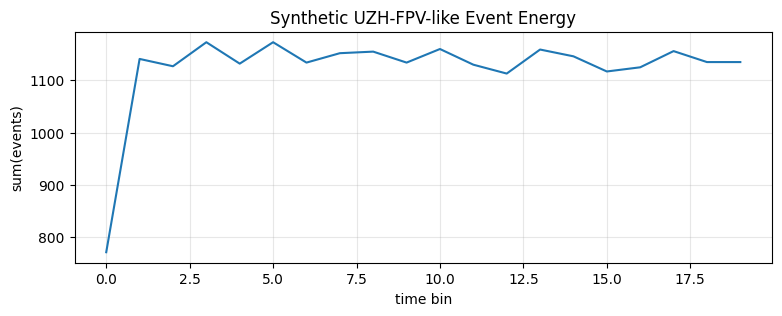

In [5]:
def synthetic_event_batch(batch=4, T=20, H=72, W=128, C=2, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.poisson(0.005, size=(T, batch, H, W, C)).astype(np.float32)

    # Inject a fast moving burst to mimic aggressive drone motion through gates.
    for t in range(T):
        col = int((W - 12) * t / max(T - 1, 1))
        row = int((H - 10) * (0.5 + 0.35 * np.sin(t / 3.0)))
        x[t, :, max(0, row - 4):row + 4, max(0, col - 6):col + 6, :] += 1.0
    return jnp.asarray(x)


def make_architectures(input_hw=(72, 128), input_channels=2, output_dim=6, beta=0.9, threshold=1.0):
    conv_cfg = fm.ConvConfig(input_hw=input_hw, input_channels=input_channels, channels1=24, channels2=48, output_dim=output_dim, beta=beta, threshold=threshold)
    sparse_cfg = fm.SparseConvConfig(input_hw=input_hw, input_channels=input_channels, channels1=24, channels2=48, output_dim=output_dim, beta=beta, threshold=threshold, event_threshold=0.0)
    dw_cfg = fm.DepthwiseSepConvConfig(input_hw=input_hw, input_channels=input_channels, depth_multiplier1=1, pointwise1=24, depth_multiplier2=1, pointwise2=48, output_dim=output_dim, beta=beta, threshold=threshold)
    residual_cfg = fm.ResidualConvConfig(input_hw=input_hw, input_channels=input_channels, stem_channels=24, block_channels=48, output_dim=output_dim, beta=beta, threshold=threshold)
    logpolar_cfg = fm.LogPolarFoveatedConvConfig(input_hw=input_hw, input_channels=input_channels, radial_bins=18, angular_bins=36, channels1=24, channels2=48, output_dim=output_dim, beta=beta, threshold=threshold)
    dual_cfg = fm.FoveatedDualPathConfig(input_hw=input_hw, input_channels=input_channels, fovea_hw=(36, 48), channels_fovea=24, channels_periphery=24, output_dim=output_dim, beta=beta, threshold=threshold)

    return {
        "conv_lif": lambda x: fm.ConvLIFSNN(conv_cfg)(x),
        "ternary_conv": lambda x: fm.TernaryConvLIFSNN(conv_cfg)(x),
        "sparse_event": lambda x: fm.SparseEventConvLIFSNN(sparse_cfg)(x),
        "depthwise_sep": lambda x: fm.DepthwiseSeparableConvLIFSNN(dw_cfg)(x),
        "residual_shallow": lambda x: fm.ResidualShallowSpikingCNN(residual_cfg)(x),
        "logpolar_foveated": lambda x: fm.LogPolarFoveatedConvSNN(logpolar_cfg)(x),
        "dual_path_foveated": lambda x: fm.FoveatedDualPathSNN(dual_cfg)(x),
    }


x = synthetic_event_batch()
frame_energy = np.asarray(x).sum(axis=(1, 2, 3, 4))
plt.figure(figsize=(9, 3))
plt.plot(frame_energy)
plt.title("Synthetic UZH-FPV-like Event Energy")
plt.xlabel("time bin")
plt.ylabel("sum(events)")
plt.grid(alpha=0.3)
plt.show()

In [6]:
def count_params(params):
    return int(sum(arr.size for arr in jax.tree_util.tree_leaves(params)))


def benchmark_model_bank(x_seq, output_dim=6):
    target = jnp.zeros((x_seq.shape[1], output_dim), dtype=jnp.float32)
    rows = []
    for name, fn in make_architectures(output_dim=output_dim).items():
        net = hk.without_apply_rng(hk.transform(fn))
        params = net.init(jax.random.PRNGKey(0), x_seq)
        pred, aux = net.apply(params, x_seq)
        rows.append({
            "model": name,
            "params": count_params(params),
            "mse_to_zero_target": float(jnp.mean((pred - target) ** 2)),
            "mean_spike_rate": float(jnp.mean(jnp.asarray(aux["spike_rate"]))),
        })
    return pd.DataFrame(rows).sort_values(["mse_to_zero_target", "params"])


benchmark_df = benchmark_model_bank(x)
benchmark_df

,model,params,mse_to_zero_target,mean_spike_rate
3,depthwise_sep,1828,0.000000e+00,0.002025
1,ternary_conv,11168,0.000000e+00,0.000055
5,logpolar_foveated,11168,1.063292e-10,0.000381
0,conv_lif,11168,3.273651e-08,0.000565
2,sparse_event,11168,3.273651e-08,0.000565
4,residual_shallow,85091,1.610486e-06,0.000358
6,dual_path_foveated,1208,1.458046e-05,0.001555


## Optuna Sweep

This study does a compact architecture sweep over several Spyx event models on the same synthetic or cached-event protocol. Replace the synthetic batch with real UZH-FPV event tensors when available.

In [ ]:
## Optuna Sweep

This study searches across FPV-relevant Spyx encoders and balances three signals:
- regression fit to a placeholder 6-DoF target
- spike efficiency
- parameter count regularization

When real UZH-FPV tensors are available, replace the synthetic batch generator with cached mDAVIS event frames and use true pose or gate-state targets.

SyntaxError: invalid syntax (1639240368.py, line 3)

In [8]:
def build_trial_model(trial):
    arch = trial.suggest_categorical(
        "arch",
        ["conv", "ternary", "sparse", "depthwise", "residual", "logpolar", "dual_path"],
    )
    channels1 = trial.suggest_categorical("channels1", [16, 24, 32])
    channels2 = trial.suggest_categorical("channels2", [32, 48, 64])
    beta = trial.suggest_float("beta", 0.78, 0.98)
    threshold = trial.suggest_float("threshold", 0.6, 1.3)
    input_hw = (72, 128)
    input_channels = 2
    output_dim = 6

    if arch == "depthwise":
        cfg = fm.DepthwiseSepConvConfig(
            input_hw=input_hw,
            input_channels=input_channels,
            depth_multiplier1=1,
            pointwise1=channels1,
            depth_multiplier2=1,
            pointwise2=channels2,
            output_dim=output_dim,
            beta=beta,
            threshold=threshold,
        )
        return lambda xb: fm.DepthwiseSeparableConvLIFSNN(cfg)(xb)

    if arch == "sparse":
        cfg = fm.SparseConvConfig(
            input_hw=input_hw,
            input_channels=input_channels,
            channels1=channels1,
            channels2=channels2,
            output_dim=output_dim,
            beta=beta,
            threshold=threshold,
            event_threshold=0.0,
        )
        return lambda xb: fm.SparseEventConvLIFSNN(cfg)(xb)

    if arch == "residual":
        cfg = fm.ResidualConvConfig(
            input_hw=input_hw,
            input_channels=input_channels,
            stem_channels=channels1,
            block_channels=channels2,
            output_dim=output_dim,
            beta=beta,
            threshold=threshold,
        )
        return lambda xb: fm.ResidualShallowSpikingCNN(cfg)(xb)

    if arch == "logpolar":
        cfg = fm.LogPolarFoveatedConvConfig(
            input_hw=input_hw,
            input_channels=input_channels,
            radial_bins=trial.suggest_categorical("radial_bins", [16, 20, 24]),
            angular_bins=trial.suggest_categorical("angular_bins", [24, 36, 48]),
            channels1=channels1,
            channels2=channels2,
            output_dim=output_dim,
            beta=beta,
            threshold=threshold,
        )
        return lambda xb: fm.LogPolarFoveatedConvSNN(cfg)(xb)

    if arch == "dual_path":
        cfg = fm.FoveatedDualPathConfig(
            input_hw=input_hw,
            input_channels=input_channels,
            fovea_hw=(36, 48),
            channels_fovea=channels1,
            channels_periphery=channels2,
            output_dim=output_dim,
            beta=beta,
            threshold=threshold,
        )
        return lambda xb: fm.FoveatedDualPathSNN(cfg)(xb)

    conv_cfg = fm.ConvConfig(
        input_hw=input_hw,
        input_channels=input_channels,
        channels1=channels1,
        channels2=channels2,
        output_dim=output_dim,
        beta=beta,
        threshold=threshold,
    )
    if arch == "ternary":
        return lambda xb: fm.TernaryConvLIFSNN(conv_cfg)(xb)
    return lambda xb: fm.ConvLIFSNN(conv_cfg)(xb)


def uzh_fpv_objective(trial):
    x_local = synthetic_event_batch(seed=trial.number)
    target = jnp.zeros((x_local.shape[1], 6), dtype=jnp.float32)
    forward = build_trial_model(trial)

    net = hk.without_apply_rng(hk.transform(forward))
    params = net.init(jax.random.PRNGKey(0), x_local)
    pred, aux = net.apply(params, x_local)

    mse = jnp.mean((pred - target) ** 2)
    spike_penalty = 0.02 * jnp.mean(jnp.asarray(aux["spike_rate"]))
    param_penalty = 1e-7 * count_params(params)
    score = mse + spike_penalty + param_penalty
    trial.set_user_attr("param_count", count_params(params))
    return float(score)


study = optuna.create_study(direction="minimize", study_name="uzh_fpv_spyx_arch_search")
study.optimize(uzh_fpv_objective, n_trials=12)
best = study.best_trial
{
    "best_params": best.params,
    "best_value": best.value,
    "best_param_count": best.user_attrs.get("param_count"),
}

[I 2026-03-24 08:01:06,381] A new study created in memory with name: uzh_fpv_spyx_arch_search
[I 2026-03-24 08:01:07,968] Trial 0 finished with value: 0.0005176585982553661 and parameters: {'arch': 'conv', 'channels1': 16, 'channels2': 32, 'beta': 0.831522758400908, 'threshold': 1.2621052792247098}. Best is trial 0 with value: 0.0005176585982553661.
[I 2026-03-24 08:01:09,056] Trial 1 finished with value: 0.0019564484246075153 and parameters: {'arch': 'sparse', 'channels1': 32, 'channels2': 64, 'beta': 0.8258380563245905, 'threshold': 1.151468730768777}. Best is trial 0 with value: 0.0005176585982553661.
[I 2026-03-24 08:01:09,233] Trial 2 finished with value: 0.0011237732833251357 and parameters: {'arch': 'sparse', 'channels1': 24, 'channels2': 48, 'beta': 0.9076659569174476, 'threshold': 1.2531334601463138}. Best is trial 0 with value: 0.0005176585982553661.
[I 2026-03-24 08:01:09,553] Trial 3 finished with value: 0.001522611826658249 and parameters: {'arch': 'conv', 'channels1': 32,

{'best_params': {'arch': 'depthwise',
  'channels1': 24,
  'channels2': 32,
  'beta': 0.9178792258586315,
  'threshold': 0.9047660816200499},
 'best_value': 0.0001803257764549926,
 'best_param_count': 1332}

## Next Steps for Real UZH-FPV Runs

1. Download public-GT starter sequences from https://fpv.ifi.uzh.ch/datasets/.
2. Prefer the public-GT subsets first: indoor forward, indoor 45 down, and outdoor forward.
3. Use ZIP/text exports for fast preprocessing into cached event tensors, or ROS bags if you want direct replay of `dvs_msgs/EventArray`, IMU, and pose streams.
4. Add calibration YAML files alongside the selected sequence family so event frames and pose targets stay sensor-consistent.
5. Replace the placeholder target with real pose, velocity, or gate-progression labels and rerun the Optuna sweep on train/validation splits.

## Real-Data Manifest + Parser Skeleton

This section upgrades the notebook from synthetic-only prototyping to a reproducible real-data pipeline.

What this adds:
- an explicit sequence manifest for public-GT subsets
- a planned download queue (manual URL fill-in from the dataset page)
- parser skeletons for ZIP/text exports and ROS bag workflows

In [9]:
# Build a concrete manifest for public-GT starter runs.
manifest_rows = []
for group, seqs in FPV_SEQUENCE_GROUPS.items():
    for seq in seqs:
        manifest_rows.append(
            {
                "group": group,
                "sequence": int(seq),
                "has_public_gt": True,
                "preferred_format": "zip_text",
                "download_url": "",  # Fill from https://fpv.ifi.uzh.ch/datasets/
                "local_subdir": f"{group}/seq_{seq:02d}",
                "use_for": "train" if seq % 3 != 0 else "val",
            }
        )

manifest_df = pd.DataFrame(manifest_rows).sort_values(["group", "sequence"]).reset_index(drop=True)
manifest_df.head(20)

manifest_path = DATA_ROOT / "manifest_public_gt.csv"
manifest_df.to_csv(manifest_path, index=False)
print("saved manifest:", manifest_path)

# Helper: quick checklist for missing URLs before any download starts.
missing_urls = manifest_df[manifest_df["download_url"].str.len() == 0]
print("rows missing download_url:", len(missing_urls))

# Optional: template commands for manual download once URLs are filled.
def build_download_commands(df: pd.DataFrame, max_rows: int = 8) -> list[str]:
    cmds = []
    for _, row in df.head(max_rows).iterrows():
        if not row["download_url"]:
            continue
        target = DATA_ROOT / row["local_subdir"]
        filename = Path(row["download_url"]).name or "archive.zip"
        cmds.append(f"mkdir -p '{target}' && curl -L '{row['download_url']}' -o '{target / filename}'")
    return cmds

download_cmds = build_download_commands(manifest_df)
print("sample download commands:")
for c in download_cmds[:5]:
    print(c)

saved manifest: ../data/UZH_FPV/manifest_public_gt.csv
rows missing download_url: 16
sample download commands:


In [10]:
from typing import Iterable


def parse_zip_text_export(sequence_dir: Path) -> dict[str, np.ndarray]:
    """Skeleton parser for ZIP/text-exported UZH-FPV sequence data.

    Expected result keys:
    - events: Nx4 array [t, x, y, p]
    - imu: Mx7 array [t, wx, wy, wz, ax, ay, az]
    - pose: Kx8 array [t, px, py, pz, qx, qy, qz, qw]
    """
    # Replace these placeholders with concrete filenames once export schema is finalized.
    events_file = sequence_dir / "events.txt"
    imu_file = sequence_dir / "imu.txt"
    pose_file = sequence_dir / "pose.txt"

    out = {
        "events": np.empty((0, 4), dtype=np.float32),
        "imu": np.empty((0, 7), dtype=np.float32),
        "pose": np.empty((0, 8), dtype=np.float32),
    }

    if events_file.exists():
        out["events"] = np.loadtxt(events_file, dtype=np.float32)
    if imu_file.exists():
        out["imu"] = np.loadtxt(imu_file, dtype=np.float32)
    if pose_file.exists():
        out["pose"] = np.loadtxt(pose_file, dtype=np.float32)
    return out


def parse_rosbag_export(bag_path: Path) -> dict[str, np.ndarray]:
    """Skeleton parser for ROS bag workflow.

    Uses `rosbags` if available; otherwise returns empty arrays and instructions.
    """
    out = {
        "events": np.empty((0, 4), dtype=np.float32),
        "imu": np.empty((0, 7), dtype=np.float32),
        "pose": np.empty((0, 8), dtype=np.float32),
        "status": "not_parsed",
    }

    try:
        from rosbags.highlevel import AnyReader  # type: ignore
    except Exception:
        out["status"] = "rosbags_not_installed"
        return out

    try:
        with AnyReader([bag_path]) as reader:
            # TODO: map actual topics from bag metadata, for example:
            # - events: dvs_msgs/EventArray
            # - imu: sensor_msgs/Imu
            # - pose: geometry_msgs/PoseStamped
            # and append decoded rows into out arrays.
            _ = list(reader.connections)
        out["status"] = "reader_opened_todo_topic_mapping"
    except Exception as exc:
        out["status"] = f"reader_failed: {type(exc).__name__}"

    return out


# Dry-run parser call on the first manifest row.
example_row = manifest_df.iloc[0]
example_dir = DATA_ROOT / example_row["local_subdir"]
example_zip_parsed = parse_zip_text_export(example_dir)
print("zip parser keys:", {k: v.shape for k, v in example_zip_parsed.items()})

example_bag = example_dir / "sequence.bag"
example_bag_parsed = parse_rosbag_export(example_bag)
print("bag parser status:", example_bag_parsed["status"])

zip parser keys: {'events': (0, 4), 'imu': (0, 7), 'pose': (0, 8)}
bag parser status: rosbags_not_installed
